In [1]:
pwd

'/Users/f0053cz/Dartmouth College Dropbox/Rekha Sreekumar Varrier/postdoc_Dartmouth/psyanim_behav_paper/version2/scripts_data_for_beh_paper/code/2_M1_M2_group_level_plots'

In [31]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [32]:
s=16 # CHANGE FONTSIZE HERE
plt.rc('font', size=s) #controls default text size
plt.rc('axes', titlesize=s) #fontsize of the title
plt.rc('axes', labelsize=s) #fontsize of the x and y labels
plt.rc('xtick', labelsize=s) #fontsize of the x tick labels
plt.rc('ytick', labelsize=s) #fontsize of the y tick labels
plt.rc('legend', fontsize=s) #fontsize of the legend

In [33]:
# root_file = '/Users/f0053cz/Documents/psyanim_v2/subtlety/subtlety_v2_data_Zishan/data/old_data/all_'
root_file = '../../data/subtlety_data/all_'
batch_name = 'apr_ses1'

In [34]:
# df = pd.read_csv('../data/all_dec_ses1.csv',index_col=[0])
df_chase = pd.read_csv(f'{root_file}{batch_name}.csv')#,index_col=[0])
df_chase.head() 

,stim_file,condition,subtlety,pred_color,slider,button_response,RT,accuracy,subID,trial_ind
0,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,black,100.0,black,3.065,1,1,0
1,75182d69-6502-4d35-9298-e331061c7829,chase,0,grey,100.0,grey,4.618,1,1,1
2,31932267-3908-4599-ba56-ba5043757838,chase,30,grey,100.0,grey,3.330,1,1,2
3,57dbdc86-9c49-4214-a908-c4a254e90229,chase,30,grey,100.0,grey,3.935,1,1,3
4,6480385b-e9eb-45a9-88e3-aade6c90476d,chase,120,black,70.0,black,4.133,1,1,4


In [38]:
df_chase.loc[np.isnan(df_chase['slider']),:].groupby(['subID']).count().sort_values(by=['stim_file'])

,stim_file,condition,subtlety,pred_color,slider,button_response,RT,accuracy,trial_ind
subID,,,,,,,,,
192,1,1,1,1,0,0,1,1,1
299,1,1,1,1,0,0,1,1,1
149,1,1,1,1,0,0,1,1,1
150,1,1,1,1,0,0,1,1,1
165,1,1,1,1,0,0,1,1,1
...,...,...,...,...,...,...,...,...,...
242,3,3,3,3,0,0,3,3,3
134,3,3,3,3,0,0,3,3,3
148,4,4,4,4,0,0,4,4,4


In [39]:
subtlety_array = np.unique(df_chase['subtlety'])
subtlety_array

array([  0,  30,  60,  90, 120, 150, 180])

In [40]:
nsubs = np.unique(df_chase['subID']).shape[0]
nsubs

312

In [41]:
len(np.unique(df_chase['subID']))

312

In [42]:
palette = {'chase':'tab:blue'}
color = 'tab:blue'

In [43]:
np.unique(df_chase['condition']) # sanity check about the no-mimic batch

array(['chase', 'wander'], dtype=object)

In [44]:
df_chase['condition'] = 'chase'

In [45]:
df_chase['slider'] = df_chase['slider']/100

In [46]:
df_chase.insert(3,'directness',0)
df_chase['directness'] = [np.round((180-i)/180,2) for i in df_chase['subtlety']]
df_chase.head()

,stim_file,condition,subtlety,directness,pred_color,slider,button_response,RT,accuracy,subID,trial_ind
0,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,1.0,black,3.065,1,1,0
1,75182d69-6502-4d35-9298-e331061c7829,chase,0,1.00,grey,1.0,grey,4.618,1,1,1
2,31932267-3908-4599-ba56-ba5043757838,chase,30,0.83,grey,1.0,grey,3.330,1,1,2
3,57dbdc86-9c49-4214-a908-c4a254e90229,chase,30,0.83,grey,1.0,grey,3.935,1,1,3
4,6480385b-e9eb-45a9-88e3-aade6c90476d,chase,120,0.33,black,0.7,black,4.133,1,1,4


In [47]:
np.unique(df_chase['directness'])

array([0.  , 0.17, 0.33, 0.5 , 0.67, 0.83, 1.  ])

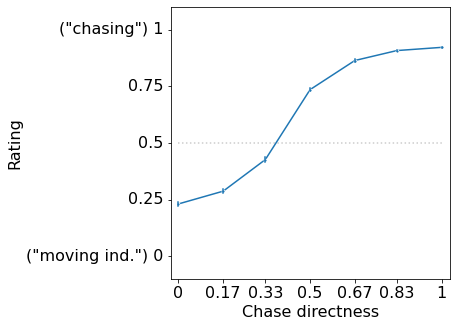

In [48]:
# sns.lineplot(data = df_chase, x = 'subtlety', y = 'slider', hue = 'condition', marker = 'o', palette=palette)
plt.figure(figsize=(5,5))
sns.lineplot(data = df_chase, x = 'directness', y = 'slider', marker = '.', color=color, err_style='bars')
# plt.hlines(50,1,180,ls=':',color = 'grey', alpha = .4)
plt.hlines(.5,0,1,ls=':',color = 'grey', alpha = .4)
# plt.ylim(-10,110)
plt.ylim(-.1,1.1)
plt.ylabel('Rating')
plt.xlabel('Chase directness')
plt.yticks(np.arange(0,1.01,.25),['("moving ind.") 0',"0.25","0.5","0.75",'("chasing") 1'],fontsize=16,va='center',ha='right')
plt.xticks(np.unique(df_chase['directness']), [str(np.round(i)).split('.')[0] if i in [0,1] else str(np.round(i,2)) for i in np.unique(df_chase['directness'])],fontsize=16, ha='center')
plt.xlim(-.03,1.03)

# Adding aligned text
ax = plt.gca()
labels = ax.get_yticklabels()

plt.savefig(f'../../results/subtlety/ratings_group_subtlety_{batch_name}.png', dpi=300, bbox_inches='tight')

In [50]:
df_chase_mean = df_chase[['subID','subtlety','directness','slider','accuracy']].groupby(['subID','subtlety']).mean().reset_index()#df_chase.groupby(['subID','subtlety']).mean().reset_index()
df_chase_mean['condition'] = 'chase'
df_chase_mean

,subID,subtlety,directness,slider,accuracy,condition
0,1,0,1.00,0.962500,1.000000,chase
1,1,30,0.83,0.964167,1.000000,chase
2,1,60,0.67,0.935833,1.000000,chase
3,1,90,0.50,0.807500,1.000000,chase
4,1,120,0.33,0.536667,1.000000,chase
...,...,...,...,...,...,...
2179,344,60,0.67,0.875000,1.000000,chase
2180,344,90,0.50,0.689167,0.916667,chase
2181,344,120,0.33,0.318333,0.833333,chase
2182,344,150,0.17,0.202500,0.583333,chase


In [51]:
dist_flname= '../../data/save_all_dist.csv'
df_dist = pd.read_csv(dist_flname, index_col=[0])
df_dist.head()

,stim_file,condition,subtlety,all_dist,avg_dist,ntimepts
0,06f1dd04-cfbc-433c-9833-32cdb01c0683,chase,90.0,"[300.0, 299.3649514, 298.53592181, 297.4219242...",251.926324,336
1,07cdb9d7-6577-428d-9498-8a7243527554,chase,0.0,"[300.0, 299.73869272, 299.36885405, 298.763735...",127.312777,336
2,0a730462-ba50-4dbe-97c6-911f61a40346,chase,30.0,"[300.0, 297.89706415, 296.26654927, 294.076685...",172.501559,336
3,0b80e3d6-cded-42b9-b7ff-67c9cdbcb3c5,chase,30.0,"[300.0, 299.08444961, 297.9048105, 296.3411155...",154.886665,335
4,0ea51ff3-f8ac-4d29-a981-0a167d74909c,chase,30.0,"[300.0, 298.33708227, 296.86725385, 294.990731...",121.558008,337


In [52]:
df_dist = df_dist[['stim_file','all_dist','avg_dist','ntimepts']]
df_dist.head()

,stim_file,all_dist,avg_dist,ntimepts
0,06f1dd04-cfbc-433c-9833-32cdb01c0683,"[300.0, 299.3649514, 298.53592181, 297.4219242...",251.926324,336
1,07cdb9d7-6577-428d-9498-8a7243527554,"[300.0, 299.73869272, 299.36885405, 298.763735...",127.312777,336
2,0a730462-ba50-4dbe-97c6-911f61a40346,"[300.0, 297.89706415, 296.26654927, 294.076685...",172.501559,336
3,0b80e3d6-cded-42b9-b7ff-67c9cdbcb3c5,"[300.0, 299.08444961, 297.9048105, 296.3411155...",154.886665,335
4,0ea51ff3-f8ac-4d29-a981-0a167d74909c,"[300.0, 298.33708227, 296.86725385, 294.990731...",121.558008,337


In [53]:
df_chase.shape, df_dist.shape

((26208, 11), (168, 4))

In [54]:
df_merged = df_chase.merge(df_dist,how = 'inner', left_on = 'stim_file', right_on = 'stim_file')
df_merged.head()

,stim_file,condition,subtlety,directness,pred_color,slider,button_response,RT,accuracy,subID,trial_ind,all_dist,avg_dist,ntimepts
0,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,1.00,black,3.065,1,1,0,"[300.0, 299.68131545, 299.42876064, 299.165219...",200.046966,335
1,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,0.84,black,5.289,1,2,20,"[300.0, 299.68131545, 299.42876064, 299.165219...",200.046966,335
2,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,0.74,black,3.600,1,3,39,"[300.0, 299.68131545, 299.42876064, 299.165219...",200.046966,335
3,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,0.98,black,3.984,1,4,9,"[300.0, 299.68131545, 299.42876064, 299.165219...",200.046966,335
4,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,1.00,black,2.471,1,5,58,"[300.0, 299.68131545, 299.42876064, 299.165219...",200.046966,335


In [55]:
len(np.unique(df_merged['stim_file']))

84

In [57]:
 # world size: 800 x 600.
max_dist = np.sqrt(800*800 + 600*600)
max_dist

1000.0

In [58]:
if df_merged['slider'].mean() > 1:
    df_merged['slider'] /= 100 
df_merged['avg_dist'] /= max_dist
df_merged['trial_ind'] /= 83
df_merged

,stim_file,condition,subtlety,directness,pred_color,slider,button_response,RT,accuracy,subID,trial_ind,all_dist,avg_dist,ntimepts
0,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,1.00,black,3.065,1,1,0.000000,"[300.0, 299.68131545, 299.42876064, 299.165219...",0.200047,335
1,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,0.84,black,5.289,1,2,0.240964,"[300.0, 299.68131545, 299.42876064, 299.165219...",0.200047,335
2,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,0.74,black,3.600,1,3,0.469880,"[300.0, 299.68131545, 299.42876064, 299.165219...",0.200047,335
3,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,0.98,black,3.984,1,4,0.108434,"[300.0, 299.68131545, 299.42876064, 299.165219...",0.200047,335
4,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,1.00,black,2.471,1,5,0.698795,"[300.0, 299.68131545, 299.42876064, 299.165219...",0.200047,335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26203,07cdb9d7-6577-428d-9498-8a7243527554,chase,0,1.00,grey,0.98,grey,3.654,1,340,0.975904,"[300.0, 299.73869272, 299.36885405, 298.763735...",0.127313,336
26204,07cdb9d7-6577-428d-9498-8a7243527554,chase,0,1.00,grey,0.91,grey,2.699,1,341,0.457831,"[300.0, 299.73869272, 299.36885405, 298.763735...",0.127313,336
26205,07cdb9d7-6577-428d-9498-8a7243527554,chase,0,1.00,grey,0.87,grey,2.998,1,342,0.481928,"[300.0, 299.73869272, 299.36885405, 298.763735...",0.127313,336
26206,07cdb9d7-6577-428d-9498-8a7243527554,chase,0,1.00,grey,0.90,grey,1.893,1,343,0.433735,"[300.0, 299.73869272, 299.36885405, 298.763735...",0.127313,336


In [59]:
df_merged[['slider','subtlety', 'directness', 'avg_dist','trial_ind']].describe()

,slider,subtlety,directness,avg_dist,trial_ind
count,26088.000000,26208.000000,26208.000000,26208.000000,26208.000000
mean,0.625056,90.000000,0.500000,0.205218,0.500000
std,0.353455,60.001145,0.332873,0.065275,0.292138
min,0.000000,0.000000,0.000000,0.121558,0.000000
25%,0.310000,30.000000,0.170000,0.152796,0.250000
50%,0.740000,90.000000,0.500000,0.189834,0.500000
75%,0.950000,150.000000,0.830000,0.251028,0.750000
max,1.000000,180.000000,1.000000,0.413494,1.000000


In [60]:
df_merged['avg_dist'].min()

0.121558007545988

In [61]:
df_merged['avg_dist'] -=  df_merged['avg_dist'].min()
df_merged['avg_dist'] /= df_merged['avg_dist'].max()
df_merged[ 'avg_dist'].describe()

count    26208.000000
mean         0.286569
std          0.223594
min          0.000000
25%          0.107002
50%          0.233872
75%          0.443486
max          1.000000
Name: avg_dist, dtype: float64

## LME

In [62]:
from pymer4.models import Lmer

In [63]:
df_merged_nonan = df_merged.loc[~np.isnan(df_merged['slider']),:]
df_merged_nonan.head()

,stim_file,condition,subtlety,directness,pred_color,slider,button_response,RT,accuracy,subID,trial_ind,all_dist,avg_dist,ntimepts
0,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,1.00,black,3.065,1,1,0.000000,"[300.0, 299.68131545, 299.42876064, 299.165219...",0.268856,335
1,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,0.84,black,5.289,1,2,0.240964,"[300.0, 299.68131545, 299.42876064, 299.165219...",0.268856,335
2,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,0.74,black,3.600,1,3,0.469880,"[300.0, 299.68131545, 299.42876064, 299.165219...",0.268856,335
3,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,0.98,black,3.984,1,4,0.108434,"[300.0, 299.68131545, 299.42876064, 299.165219...",0.268856,335
4,c53236a2-f564-41ec-89aa-2bd90765b0a4,chase,30,0.83,black,1.00,black,2.471,1,5,0.698795,"[300.0, 299.68131545, 299.42876064, 299.165219...",0.268856,335


In [64]:
df_merged_nonan.shape, df_merged.shape

((26088, 14), (26208, 14))

In [65]:
model = Lmer('slider ~ directness + trial_ind + (1|subID) + (1|stim_file)', data=df_merged_nonan) # without mean dist
model.fit()

Formula: slider~directness+trial_ind+(1|subID)+(1|stim_file)

Family: gaussian	 Inference: parametric

Number of observations: 26088	 Groups: {'subID': 312.0, 'stim_file': 84.0}

Log-likelihood: 6146.612 	 AIC: -12293.224

Random effects:

                  Name    Var    Std
subID      (Intercept)  0.005  0.068
stim_file  (Intercept)  0.014  0.118
Residual                0.035  0.187

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.223,0.176,0.269,0.024,87.754,9.406,0.000,***
directness,0.805,0.729,0.881,0.039,81.998,20.787,0.000,***
trial_ind,-0.001,-0.009,0.007,0.004,25693.375,-0.281,0.779,


In [69]:
from scipy import stats

In [76]:
stim_dist_corr = df_merged.groupby(["stim_file"]).mean()
print(stim_dist_corr.shape)
stim_dist_corr.head()

(84, 9)


,subtlety,directness,slider,RT,accuracy,subID,trial_ind,avg_dist,ntimepts
stim_file,,,,,,,,,
00139b14-fa60-4af8-9eba-0b4965060c34,180.0,0.00,0.203119,3.520240,0.503205,172.541667,0.509886,0.430583,6671.0
00ccc21a-d63a-41eb-8d3b-a2315d7b0d3e,180.0,0.00,0.110000,3.499994,0.439103,172.541667,0.518343,0.745833,6650.0
06f1dd04-cfbc-433c-9833-32cdb01c0683,90.0,0.50,0.742194,3.291093,0.935897,172.541667,0.487257,0.446564,336.0
07cdb9d7-6577-428d-9498-8a7243527554,0.0,1.00,0.927404,3.087362,0.977564,172.541667,0.498378,0.019712,336.0
0a730462-ba50-4dbe-97c6-911f61a40346,30.0,0.83,0.907903,3.188022,0.967949,172.541667,0.492663,0.174502,336.0


In [79]:
# mean-distance - directness correlation
# stats.pearsonr(df_merged['avg_dist'],df_merged['directness']) # with duplicates, deflates pvalues wrongly
stats.pearsonr(stim_dist_corr['avg_dist'],stim_dist_corr['directness'])

(-0.6939097336555088, 0.0)

In [83]:
stats.spearmanr(stim_dist_corr['avg_dist'],stim_dist_corr['directness'])

SpearmanrResult(correlation=-0.7124103828483346, pvalue=2.976590414193943e-14)

In [66]:
#with avg dist
model = Lmer('slider ~ directness + avg_dist + trial_ind + (1|subID) + (1|stim_file)', data=df_merged_nonan)
model.fit()

Formula: slider~directness+avg_dist+trial_ind+(1|subID)+(1|stim_file)

Family: gaussian	 Inference: parametric

Number of observations: 26088	 Groups: {'subID': 312.0, 'stim_file': 84.0}

Log-likelihood: 6162.701 	 AIC: -12325.403

Random effects:

                  Name    Var    Std
subID      (Intercept)  0.005  0.068
stim_file  (Intercept)  0.009  0.095
Residual                0.035  0.187

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.447,0.371,0.523,0.039,83.049,11.515,0.000,***
directness,0.604,0.519,0.689,0.044,81.003,13.886,0.000,***
avg_dist,-0.431,-0.558,-0.305,0.065,81.003,-6.661,0.000,***
trial_ind,-0.001,-0.009,0.007,0.004,25693.978,-0.277,0.782,


In [80]:
# comparison with the model without directness
#with avg dist
model = Lmer('slider ~  avg_dist + trial_ind + (1|subID) + (1|stim_file)', data=df_merged_nonan)
model.fit()

Formula: slider~avg_dist+trial_ind+(1|subID)+(1|stim_file)

Family: gaussian	 Inference: parametric

Number of observations: 26088	 Groups: {'subID': 312.0, 'stim_file': 84.0}

Log-likelihood: 6114.982 	 AIC: -12229.964

Random effects:

                  Name    Var    Std
subID      (Intercept)  0.005  0.068
stim_file  (Intercept)  0.030  0.174
Residual                0.035  0.187

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,DF,T-stat,P-val,Sig
(Intercept),0.928,0.866,0.989,0.031,85.211,29.661,0.000,***
avg_dist,-1.056,-1.223,-0.889,0.085,81.998,-12.385,0.000,***
trial_ind,-0.001,-0.009,0.007,0.004,25692.751,-0.280,0.779,


# Accuracy

In [51]:
subtlety_array

array([  0,  30,  60,  90, 120, 150, 180])

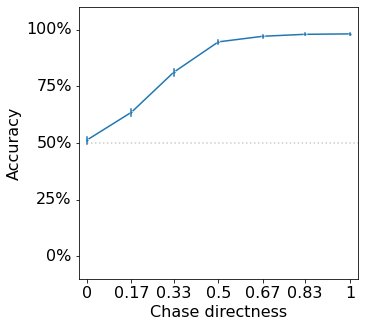

In [84]:
plt.figure(figsize=(5,5))
sns.lineplot(data = df_chase_mean, x = 'directness', y = 'accuracy', hue = 'condition', marker = '.', palette=palette, legend=False, err_style='bars')
plt.hlines(.5,0,1.1,ls=':',color = 'grey', alpha = .4)
plt.ylim(-.1,1.1)
plt.ylabel('Accuracy')
plt.xlabel('Chase directness')
plt.yticks(np.arange(0,1.1,.25),['0%',"25%","50%","75%",'100%'],fontsize=16,va='center',ha='right')

plt.xticks(np.unique(df_chase['directness']), [str(np.round(i)).split('.')[0] if i in [0,1] else str(np.round(i,2)) for i in np.unique(df_chase['directness'])],fontsize=16, ha='center')
plt.xlim(-.03,1.03)

# Adding aligned text
ax = plt.gca()
labels = ax.get_yticklabels()

# Optionally, you can also align horizontally
labels = ax.get_xticklabels()
labels[-1].set_ha('center')  # Right-aligned

plt.savefig(f'../../results/subtlety/accuracy_group_subtlety_{batch_name}.png', dpi=300, bbox_inches='tight')

In [85]:
# without avg dist
model = Lmer('accuracy ~ directness + trial_ind + (1|subID) + (1|stim_file)', data=df_merged_nonan, family='binomial')
model.fit()

Formula: accuracy~directness+trial_ind+(1|subID)+(1|stim_file)

Family: binomial	 Inference: parametric

Number of observations: 26088	 Groups: {'subID': 312.0, 'stim_file': 84.0}

Log-likelihood: -7985.681 	 AIC: 15981.362

Random effects:

                  Name    Var    Std
subID      (Intercept)  0.107  0.326
stim_file  (Intercept)  0.574  0.757

No random effect correlations specified

Fixed effects:



,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.094,-0.217,0.405,0.159,1.099,0.805,1.500,0.524,0.446,0.600,0.593,0.553,
directness,4.735,4.202,5.268,0.272,113.891,66.852,194.028,0.991,0.985,0.995,17.420,0.000,***
trial_ind,0.182,0.045,0.319,0.070,1.200,1.046,1.376,0.545,0.511,0.579,2.607,0.009,**


In [77]:
model = Lmer('accuracy ~ directness + avg_dist + trial_ind + (1|subID) + (1|stim_file)', data=df_merged_nonan, family='binomial')
model.fit()

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: accuracy~directness+avg_dist+trial_ind+(1|subID)+(1|stim_file)

Family: binomial	 Inference: parametric

Number of observations: 26088	 Groups: {'subID': 312.0, 'stim_file': 84.0}

Log-likelihood: -7984.783 	 AIC: 15981.566

Random effects:

                  Name    Var    Std
subID      (Intercept)  0.107  0.326
stim_file  (Intercept)  0.563  0.751

No random effect correlations specified

Fixed effects:



/Users/f0053cz/miniconda3/envs/pymer4/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,Estimate,2.5_ci,97.5_ci,SE,OR,OR_2.5_ci,OR_97.5_ci,Prob,Prob_2.5_ci,Prob_97.5_ci,Z-stat,P-val,Sig
(Intercept),0.469,-0.160,1.098,0.321,1.598,0.852,2.999,0.615,0.460,0.750,1.461,0.144,
directness,4.396,3.672,5.121,0.369,81.160,39.340,167.434,0.988,0.975,0.994,11.899,0.000,***
avg_dist,-0.716,-1.761,0.329,0.533,0.489,0.172,1.390,0.328,0.147,0.582,-1.343,0.179,
trial_ind,0.182,0.045,0.319,0.070,1.200,1.046,1.376,0.545,0.511,0.579,2.607,0.009,**
